In [25]:
# import packages and BTMS_model
import os
import sys
import io
import contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath("../..")
sys.path.append(PROJECT_ROOT)

import lib.BTMS_model as BTMS_model
import CoolProp.CoolProp as CP

In [26]:
# result-file naming configuration
# This notebook evaluates one fixed AC-PARK design condition using the same 1D calculation logic as C0004.
CASE_ID = 'C0008'
REVISION = 'R01'
RESULT_ID = f'{CASE_ID}{REVISION}'
SCENARIO_CODE = 'PARK25'
BTMS_CODE = 'AC'
MODEL_CODE = '1D'
TASK_CODE = 'EVAL'
RESULT_BASENAME = f'{RESULT_ID}_{SCENARIO_CODE}_{BTMS_CODE}_{MODEL_CODE}_{TASK_CODE}'
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'out', CASE_ID)
RESULT_FIGURE_NAME = f'{RESULT_BASENAME}.png'

# CFD data used for comparison. These CFD files must correspond to the same operating condition used below.
CFD_DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'C0014', 'C0014R00_PARK25_AC_THERM_CFD_EVAL')

print(f'Result basename: {RESULT_BASENAME}')
print(f'Temperature-curve figure: {RESULT_FIGURE_NAME}')

Result basename: C0008R01_PARK25_AC_1D_EVAL
Temperature-curve figure: C0008R01_PARK25_AC_1D_EVAL.png


In [27]:
# read Qbat(W) from the data file
SIM_DURATION_S = 1920.0
DT = 1.0
NUM_STEPS = int(round(SIM_DURATION_S / DT))
if not np.isclose(NUM_STEPS * DT, SIM_DURATION_S):
    raise ValueError('SIM_DURATION_S must be an integer multiple of DT.')

SIM_TIME_S = NUM_STEPS
dt = DT
file_name = os.path.join(PROJECT_ROOT, 'data', 'MD05E070207A1  data_power gen_single cell_Liu_20260421.xlsx')
df = pd.read_excel(file_name, sheet_name='Sheet1')
power_generation_data_1s = df['Qbat(W)'].dropna().to_numpy(dtype=float)
if len(power_generation_data_1s) == 0:
    raise ValueError('The Qbat(W) column does not contain valid heat-generation data.')

time_s = np.arange(SIM_TIME_S + 1) * dt
power_indices = np.floor(time_s[:-1]).astype(int)
power_indices = np.clip(power_indices, 0, len(power_generation_data_1s) - 1)
power_generation_data = power_generation_data_1s[power_indices]

print(f'Simulation duration: {SIM_DURATION_S:.1f} s')
print(f'Time step dt: {dt:.3f} s')
print(f'Number of numerical steps: {SIM_TIME_S}')
print(f'Q_gen array length: {len(power_generation_data)}')

Simulation duration: 1920.0 s
Time step dt: 1.000 s
Number of numerical steps: 1920
Q_gen array length: 1920


In [28]:
# model settings and AC-PARK evaluation conditions
BATTERY_PROPS = {'m_bat': 48e-3, 'cp_bat': 830.0, 'D_bat': 18e-3, 'H_bat': 65e-3}
MODULE_LAYOUT = {'N_r': 16, 'N_c': 20, 'num_cell_seg': 1.0}
AIR_SETTINGS = {'fluid': 'Air', 'p_air': 101325.0, 'fan_efficiency': 0.35}
BOTTOM_PLATE_SETTINGS = {'t_plate': 2.0e-3, 'rho_plate': 2700.0}
SOLVER_SETTINGS = {'solver_tol': 1e-6, 'solver_maxiter': 1000}

# Current AC-PARK optimal design selected from C0004 parametric scan.
EVALUATION_CASE = {'case_id': RESULT_ID, 'V_air': 1.5, 'T_air': 25.0, 's_gap_mm': 2.0, 'cooling_mode': 'all_mission'}

# Baseline condition from "BTMS eval vs power generation.ipynb": V_air=1.5 m/s, T_air=25 degC,
# S_T=1.25*D_bat=22.5 mm -> surface gap=4.5 mm, with cooling active only during cruise (180-1560 s).
BASELINE_CASE = {'case_id': f'{RESULT_ID}_BASELINE', 'V_air': 1.5, 'T_air': 25.0, 's_gap_mm': 4.5, 'cooling_mode': 'cruise_only'}

m_bat = BATTERY_PROPS['m_bat']
cp_bat = BATTERY_PROPS['cp_bat']
D_bat = BATTERY_PROPS['D_bat']
H_bat = BATTERY_PROPS['H_bat']
A_battery = np.pi * D_bat * H_bat
N_r = MODULE_LAYOUT['N_r']
N_c = MODULE_LAYOUT['N_c']
num_seg = N_c
num_cell_seg = MODULE_LAYOUT['num_cell_seg']
fluid = AIR_SETTINGS['fluid']
p_air = AIR_SETTINGS['p_air']
fan_efficiency = AIR_SETTINGS['fan_efficiency']
t_bottom_plate = BOTTOM_PLATE_SETTINGS['t_plate']
rho_bottom_plate = BOTTOM_PLATE_SETTINGS['rho_plate']
solver_tol = SOLVER_SETTINGS['solver_tol']
solver_maxiter = SOLVER_SETTINGS['solver_maxiter']
t_cruise_start = 180.0
t_cruise_end = 1560.0
case_id = EVALUATION_CASE['case_id']
V_air = float(EVALUATION_CASE['V_air'])
T_air = float(EVALUATION_CASE['T_air'])
s_gap_mm = float(EVALUATION_CASE['s_gap_mm'])

print('Optimal evaluation case:')
print(f'  case_id = {case_id}')
print(f'  V_air = {V_air:.3f} m/s')
print(f'  T_air = {T_air:.3f} degC')
print(f'  s_gap = {s_gap_mm:.3f} mm')
print(f"  cooling_mode = {EVALUATION_CASE['cooling_mode']}")
print('Baseline evaluation case:')
print(f"  case_id = {BASELINE_CASE['case_id']}")
print(f"  V_air = {BASELINE_CASE['V_air']:.3f} m/s")
print(f"  T_air = {BASELINE_CASE['T_air']:.3f} degC")
print(f"  s_gap = {BASELINE_CASE['s_gap_mm']:.3f} mm")
print(f"  cooling_mode = {BASELINE_CASE['cooling_mode']}")


Optimal evaluation case:
  case_id = C0008R01
  V_air = 1.500 m/s
  T_air = 25.000 degC
  s_gap = 2.000 mm
  cooling_mode = all_mission
Baseline evaluation case:
  case_id = C0008R01_BASELINE
  V_air = 1.500 m/s
  T_air = 25.000 degC
  s_gap = 4.500 mm
  cooling_mode = cruise_only


In [29]:
# horizontal flight-velocity profile used by the supplementary fan-power model in C0004
def get_horizontal_flight_velocity(t):
    V_190 = 190.0 / 3.6
    V_241 = 241.0 / 3.6
    if t < 6.0:
        V_x = 0.0
    elif t < 36.0:
        V_x = V_190 * (t - 6.0) / 30.0
    elif t < 180.0:
        V_x = V_190 + (V_241 - V_190) * (t - 36.0) / 144.0
    elif t < 1560.0:
        V_x = V_241
    elif t < 1704.0:
        V_x = V_241 - (V_241 - V_190) * (t - 1560.0) / 144.0
    elif t < 1734.0:
        V_x = V_190 * (1.0 - (t - 1704.0) / 30.0)
    else:
        V_x = 0.0
    return V_x

Vx_profile = np.array([get_horizontal_flight_velocity(t) for t in time_s[:-1]])

In [30]:
# calculate the fixed inlet-air properties once
T_air_K = T_air + 273.15
mu_air = CP.PropsSI('V', 'T', T_air_K, 'P', p_air, fluid)
rho_air = CP.PropsSI('D', 'T', T_air_K, 'P', p_air, fluid)
cp_air = CP.PropsSI('C', 'T', T_air_K, 'P', p_air, fluid)
k_air = CP.PropsSI('L', 'T', T_air_K, 'P', p_air, fluid)
Pr_air = cp_air * mu_air / k_air
air_props = {'mu_air': mu_air, 'rho_air': rho_air, 'cp_air': cp_air, 'k_air': k_air, 'Pr_air': Pr_air}
print('Air properties calculated for the fixed inlet condition.')

Air properties calculated for the fixed inlet condition.


In [31]:
# run one AC-PARK evaluation case using the same calculation logic as C0004
def run_evaluation_case(case_id, V_air, T_air, s_gap_mm, cooling_mode='all_mission'):
    s_gap = s_gap_mm * 1e-3

    # Staggered geometry: S_T = S_D = D_bat + s_gap and S_L = sqrt(3)/2 * S_T.
    S_T = D_bat + s_gap
    S_D = S_T
    S_L = np.sqrt(3.0) / 2.0 * S_T
    L_module = D_bat + (N_c - 1) * S_L
    W_module = D_bat + (N_r - 1) * S_T
    A_air = W_module * H_bat
    W_air_channel = W_module / N_r
    H_air_channel = H_bat
    A_cool = W_air_channel * H_air_channel

    # Heat-transfer coefficient: identical to C0004.
    Re_air = air_props['rho_air'] * V_air * D_bat / air_props['mu_air']
    eps_air = BTMS_model.select_correction_factor(no_col=N_c, Re=Re_air)
    Nu_air = BTMS_model.zukauskas_nusellet(Re_air, air_props['Pr_air'], eps_air, air_props['Pr_air'])
    h_air = Nu_air * air_props['k_air'] / D_bat
    htc_cool = np.ones(num_seg) * h_air

    # Fan inlet area: keep the same fixed Park reference geometry used by C0004 fan-power calculation.
    S_T_power = 1.25 * D_bat
    W_module_power = D_bat + (N_r - 1) * S_T_power
    A_in_power = W_module_power * H_bat

    # Initial battery and cooling-air temperatures are equal to the inlet-air temperature.
    T_bat = np.ones(num_seg) * T_air
    T_cool = np.ones(num_seg) * T_air
    T_bat_history = np.zeros((SIM_TIME_S + 1, num_seg))
    T_air_history = np.zeros((SIM_TIME_S + 1, num_seg))
    T_bat_history[0, :] = T_bat
    T_air_history[0, :] = T_cool
    E_fan_cumulative = 0.0

    for k in range(SIM_TIME_S):
        t = time_s[k]
        if cooling_mode == 'all_mission':
            is_cool = True
        elif cooling_mode == 'cruise_only':
            is_cool = (t >= t_cruise_start) and (t <= t_cruise_end)
        else:
            raise ValueError(f'Unsupported cooling_mode: {cooling_mode}')
        V_x = Vx_profile[k]
        fan_args = {'rho_air': air_props['rho_air'], 'mu_air': air_props['mu_air'], 'V_air_in': V_air, 'V_x': V_x, 'D_bat': D_bat, 'N_c': N_c, 'A_in': A_in_power, 'fan_efficiency': fan_efficiency}
        fan_results = BTMS_model.cal_air_fan_supplement_power(fan_args)
        P_fan = fan_results['P_fan_W'] if is_cool else 0.0
        E_fan_cumulative += P_fan * dt
        args = {'num_seg': num_seg, 'num_seg_bat': num_seg, 'dt': dt, 'T_cool_pre': T_cool, 'T_bat_pre': T_bat, 'u_cool_in': V_air, 'p_cool': p_air, 'fluid_cool': fluid, 'A_HT_seg': A_battery, 'A_cool_cs': A_cool, 'm_bat': m_bat, 'cp_bat': cp_bat, 'D_bat': D_bat, 'T_cool_in': T_air, 'T_cool_out': max(float(T_cool[-1]), T_air), 'is_cool': is_cool, 'htc_cool': htc_cool, 'cp_cool': air_props['cp_air'], 'rho_cool': air_props['rho_air'], 'Q_gen': power_generation_data[k], 'num_cell_seg': num_cell_seg, 'debug': False}
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                T_dist = BTMS_model.solve_coolant_temperature_distribution(args, tol=solver_tol, maxiter=solver_maxiter, debug=False)
        except Exception as e:
            print('\nSolver failed inside run_evaluation_case.')
            print(f'case_id = {case_id}')
            print(f'V_air = {V_air} m/s')
            print(f'T_air_in = {T_air} degC')
            print(f's_gap = {s_gap_mm} mm')
            print(f'cooling_mode = {cooling_mode}')
            print(f'is_cool = {is_cool}')
            print(f'time step k = {k}')
            print(f't = {t:.1f} s')
            print(f'Q_gen = {power_generation_data[k]} W')
            print(f'Re_air = {Re_air}')
            print(f'h_air = {h_air}')
            print(f'S_D = {S_D}')
            print(f'S_T = {S_T}')
            print(f'S_L = {S_L}')
            print(f'L_module = {L_module}')
            print(f'W_module = {W_module}')
            print(f'A_air = {A_air}')
            print(f'A_cool = {A_cool}')
            print(f'V_x = {V_x}')
            print(f'P_fan = {P_fan}')
            print(f'delta_p_ram = {fan_results["delta_p_ram_Pa"]}')
            print(f'delta_p_fan = {fan_results["delta_p_fan_Pa"]}')
            print(f'T_bat_min/max before solve = {np.min(T_bat)}, {np.max(T_bat)}')
            print(f'T_cool_min/max before solve = {np.min(T_cool)}, {np.max(T_cool)}')
            print(f'error = {repr(e)}')
            raise

        T_dist = np.asarray(T_dist, dtype=float)
        if not np.all(np.isfinite(T_dist)):
            raise FloatingPointError(f'Non-finite values detected at t={t:.1f} s: min={np.nanmin(T_dist)}, max={np.nanmax(T_dist)}')
        T_cool = T_dist[:num_seg]
        T_bat = T_dist[num_seg:]
        T_bat_history[k + 1, :] = T_bat
        T_air_history[k + 1, :] = T_cool

    Tmax = np.max(T_bat_history, axis=1)
    Tmin = np.min(T_bat_history, axis=1)
    DeltaT = Tmax - Tmin
    Tair_out = T_air_history[:, -1]
    m_bottom_plate = rho_bottom_plate * L_module * W_module * t_bottom_plate
    return {'time_s': time_s.copy(), 'Tmax_C': Tmax, 'Tmin_C': Tmin, 'DeltaT_C': DeltaT, 'Tair_out_C': Tair_out, 'E_fan_cumulative_J': float(E_fan_cumulative), 'E_fan_cumulative_kJ': float(E_fan_cumulative / 1000.0), 'Re_air': float(Re_air), 'Nu_air': float(Nu_air), 'h_air_W_m2K': float(h_air), 'S_T_mm': float(S_T * 1e3), 'S_D_mm': float(S_D * 1e3), 'S_L_mm': float(S_L * 1e3), 'L_module_m': float(L_module), 'W_module_m': float(W_module), 'm_bottom_plate_kg': float(m_bottom_plate), 'cooling_mode': cooling_mode}


In [32]:
# execute the optimal and baseline evaluation cases
print(f'Running optimal evaluation case {case_id}: V_air={V_air} m/s, T_air={T_air} degC, s_gap={s_gap_mm} mm')
results = run_evaluation_case(case_id=case_id, V_air=V_air, T_air=T_air, s_gap_mm=s_gap_mm, cooling_mode=EVALUATION_CASE['cooling_mode'])
peak_index = int(np.argmax(results['Tmax_C']))
print('Optimal evaluation case completed.')
print(f"Maximum mission temperature: {results['Tmax_C'][peak_index]:.3f} degC")
print(f"Maximum mission temperature difference: {np.max(results['DeltaT_C']):.3f} degC")
print(f"Cumulative fan energy: {results['E_fan_cumulative_kJ']:.3f} kJ")
print(f"Bottom-plate mass: {results['m_bottom_plate_kg']:.3f} kg")
print(f"Time of maximum temperature: {results['time_s'][peak_index]:.1f} s")
print(f"Minimum-cell temperature at final time: {results['Tmin_C'][-1]:.3f} degC")

baseline_case_id = BASELINE_CASE['case_id']
baseline_V_air = float(BASELINE_CASE['V_air'])
baseline_T_air = float(BASELINE_CASE['T_air'])
baseline_s_gap_mm = float(BASELINE_CASE['s_gap_mm'])
print()
print(f'Running baseline evaluation case {baseline_case_id}: V_air={baseline_V_air} m/s, T_air={baseline_T_air} degC, s_gap={baseline_s_gap_mm} mm')
baseline_results = run_evaluation_case(case_id=baseline_case_id, V_air=baseline_V_air, T_air=baseline_T_air, s_gap_mm=baseline_s_gap_mm, cooling_mode=BASELINE_CASE['cooling_mode'])
baseline_peak_index = int(np.argmax(baseline_results['Tmax_C']))
print('Baseline evaluation case completed.')
print(f"Maximum mission temperature: {baseline_results['Tmax_C'][baseline_peak_index]:.3f} degC")
print(f"Maximum mission temperature difference: {np.max(baseline_results['DeltaT_C']):.3f} degC")
print(f"Cumulative fan energy: {baseline_results['E_fan_cumulative_kJ']:.3f} kJ")
print(f"Bottom-plate mass: {baseline_results['m_bottom_plate_kg']:.3f} kg")
print(f"Time of maximum temperature: {baseline_results['time_s'][baseline_peak_index]:.1f} s")
print(f"Minimum-cell temperature at final time: {baseline_results['Tmin_C'][-1]:.3f} degC")


Running optimal evaluation case C0008R01: V_air=1.5 m/s, T_air=25.0 degC, s_gap=2.0 mm
Optimal evaluation case completed.
Maximum mission temperature: 44.787 degC
Maximum mission temperature difference: 3.508 degC
Cumulative fan energy: 1.370 kJ
Bottom-plate mass: 0.596 kg
Time of maximum temperature: 1920.0 s
Minimum-cell temperature at final time: 41.278 degC

Running baseline evaluation case C0008R01_BASELINE: V_air=1.5 m/s, T_air=25.0 degC, s_gap=4.5 mm
Baseline evaluation case completed.
Maximum mission temperature: 48.470 degC
Maximum mission temperature difference: 2.036 degC
Cumulative fan energy: 0.000 kJ
Bottom-plate mass: 0.745 kg
Time of maximum temperature: 1920.0 s
Minimum-cell temperature at final time: 46.434 degC


Loaded CFD_max: 1921 points, time = 0.0-1920.0 s
Loaded CFD_min: 1921 points, time = 0.0-1920.0 s


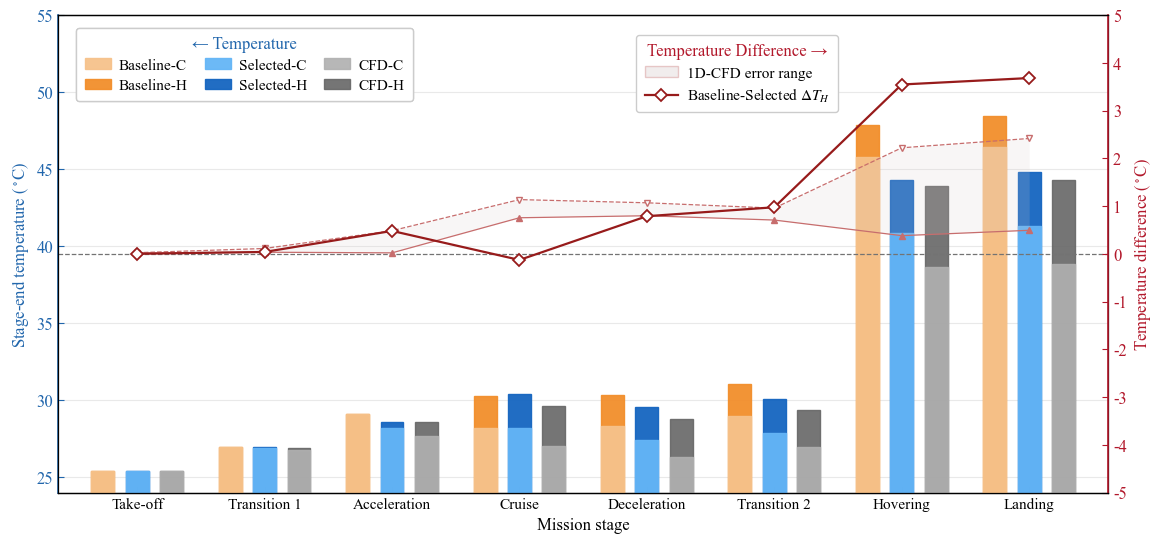


===== Baseline =====
Baseline-H: [25.419 26.991 29.085 30.249 30.345 31.023 47.847 48.47 ]
Baseline-C: [25.419 26.991 29.085 28.213 28.308 28.987 45.81  46.434]

===== Selected 1D =====
Selected-H: [25.417 26.951 28.603 30.376 29.555 30.046 44.299 44.787]
Selected-C: [25.416 26.909 28.179 28.177 27.393 27.895 40.87  41.278]

===== CFD =====
CFD-H: [25.397 26.916 28.582 29.619 28.756 29.338 43.917 44.293]
CFD-C: [25.391 26.795 27.693 27.04  26.323 26.937 38.648 38.861]

===== 1D - CFD prediction error =====
1D-CFD Delta-H: [0.021 0.035 0.022 0.757 0.799 0.709 0.382 0.494]
1D-CFD Delta-C: [0.025 0.113 0.486 1.137 1.07  0.958 2.222 2.418]

===== Baseline - Selected Tmax reduction =====
Baseline-Selected Delta-H: [ 2.000e-03  4.000e-02  4.810e-01 -1.270e-01  7.900e-01  9.770e-01
  3.548e+00  3.683e+00]

Saved figure: d:\eBATS\out\C0008\C0008R01_PARK25_AC_1D_EVAL_COMBINED_COMPARE.png
Saved figure: d:\eBATS\out\C0008\C0008R01_PARK25_AC_1D_EVAL_COMBINED_COMPARE.pdf


In [48]:
# ============================================================
# Cell 8 - Baseline / Selected 1D / CFD Comparison
#
# Bars:
#   Baseline / Selected / CFD stage-end Tmax and Tmin
#
# Right axis:
#   Shaded band : 1D - CFD prediction error range
#   Line        : Baseline - Selected Tmax reduction
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# output
# ------------------------------------------------------------
os.makedirs(OUTPUT_DIR, exist_ok=True)

figure_path = os.path.join(OUTPUT_DIR, f'{RESULT_BASENAME}_COMBINED_COMPARE.png')
figure_path_pdf = os.path.join(OUTPUT_DIR, f'{RESULT_BASENAME}_COMBINED_COMPARE.pdf')

font_size = 12

# ------------------------------------------------------------
# mission stages
# ------------------------------------------------------------
stage_boundaries = np.array([6.0, 36.0, 180.0, 1560.0, 1704.0, 1734.0, 1914.0, 1920.0])
stage_labels = ['Take-off', 'Transition 1', 'Acceleration', 'Cruise', 'Deceleration', 'Transition 2', 'Hovering', 'Landing']
x = np.arange(len(stage_labels))

# ------------------------------------------------------------
# read CFD data
# ------------------------------------------------------------
def read_cfd_out(file_path, curve_name):
    rows = []

    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith(('"', '(', ')', '#')):
                continue

            values = line.replace(',', ' ').split()

            if len(values) < 3:
                continue

            try:
                temperature = float(values[1])
                flow_time = float(values[2])
            except ValueError:
                continue

            rows.append((flow_time, temperature))

    if not rows:
        raise ValueError(f'No valid CFD data were read from {file_path}.')

    data = pd.DataFrame(rows, columns=['time_s', 'temperature'])
    data = data.drop_duplicates(subset='time_s', keep='last').sort_values('time_s')

    if data['temperature'].mean() > 200.0:
        data['temperature_C'] = data['temperature'] - 273.15
    else:
        data['temperature_C'] = data['temperature']

    print(f'Loaded {curve_name}: {len(data)} points, time = {data["time_s"].min():.1f}-{data["time_s"].max():.1f} s')

    return data[['time_s', 'temperature_C']].reset_index(drop=True)


CFD_FILES = {
    'CFD_max': os.path.join(CFD_DATA_DIR, 'max.out'),
    'CFD_min': os.path.join(CFD_DATA_DIR, 'min.out')
}

cfd_temperature_data = {curve_name: read_cfd_out(file_path, curve_name) for curve_name, file_path in CFD_FILES.items()}

# ------------------------------------------------------------
# stage-end temperatures
# ------------------------------------------------------------
selected_h_end = np.interp(stage_boundaries, results['time_s'], results['Tmax_C'])
selected_c_end = np.interp(stage_boundaries, results['time_s'], results['Tmin_C'])

baseline_h_end = np.interp(stage_boundaries, baseline_results['time_s'], baseline_results['Tmax_C'])
baseline_c_end = np.interp(stage_boundaries, baseline_results['time_s'], baseline_results['Tmin_C'])

cfd_h_end = np.interp(stage_boundaries, cfd_temperature_data['CFD_max']['time_s'], cfd_temperature_data['CFD_max']['temperature_C'])
cfd_c_end = np.interp(stage_boundaries, cfd_temperature_data['CFD_min']['time_s'], cfd_temperature_data['CFD_min']['temperature_C'])

# ------------------------------------------------------------
# temperature differences
# ------------------------------------------------------------
delta_h_end = selected_h_end - cfd_h_end
delta_c_end = selected_c_end - cfd_c_end
delta_baseline_selected_h_end = baseline_h_end - selected_h_end

# ------------------------------------------------------------
# 1D-CFD error-band limits
# ------------------------------------------------------------
delta_error_low = np.minimum(delta_h_end, delta_c_end)
delta_error_high = np.maximum(delta_h_end, delta_c_end)

# ------------------------------------------------------------
# plot settings
# ------------------------------------------------------------
plt.rcdefaults()

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': font_size,
    'axes.labelsize': font_size,
    'axes.titlesize': font_size,
    'xtick.labelsize': font_size - 1,
    'ytick.labelsize': font_size,
    'axes.linewidth': 0.9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.unicode_minus': False
})

left_axis_color = '#2166AC'
right_axis_color = '#B2182B'

# ------------------------------------------------------------
# figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12.5, 6.2))
fig.subplots_adjust(left=0.08, right=0.92, bottom=0.18, top=0.95)

# ------------------------------------------------------------
# bar positions
# ------------------------------------------------------------
group_offset = 0.27
bar_w = 0.18

x_baseline = x - group_offset
x_selected = x
x_cfd = x + group_offset

# ------------------------------------------------------------
# colors
# ------------------------------------------------------------
baseline_h_color = '#F28E2B'
baseline_c_color = '#F6C28B'

selected_h_color = '#1565C0'
selected_c_color = '#64B5F6'

cfd_h_color = '#666666'
cfd_c_color = '#B0B0B0'

error_band_color = '#D8CCCC'
error_boundary_color = '#C76D6D'
improvement_color = '#971B1B'

# ------------------------------------------------------------
# Baseline temperature bars
# ------------------------------------------------------------
bars_baseline_h = ax.bar(x_baseline, baseline_h_end, width=bar_w, color=baseline_h_color, edgecolor=baseline_h_color, alpha=0.95, label='Baseline-H', zorder=3)
bars_baseline_c = ax.bar(x_baseline, baseline_c_end, width=bar_w, color=baseline_c_color, edgecolor=baseline_c_color, alpha=0.95, label='Baseline-C', zorder=4)

# ------------------------------------------------------------
# Selected temperature bars
# ------------------------------------------------------------
bars_selected_h = ax.bar(x_selected, selected_h_end, width=bar_w, color=selected_h_color, edgecolor=selected_h_color, alpha=0.95, label='Selected-H', zorder=3)
bars_selected_c = ax.bar(x_selected, selected_c_end, width=bar_w, color=selected_c_color, edgecolor=selected_c_color, alpha=0.95, label='Selected-C', zorder=4)

# ------------------------------------------------------------
# CFD temperature bars
# ------------------------------------------------------------
bars_cfd_h = ax.bar(x_cfd, cfd_h_end, width=bar_w, color=cfd_h_color, edgecolor=cfd_h_color, alpha=0.90, label='CFD-H', zorder=3)
bars_cfd_c = ax.bar(x_cfd, cfd_c_end, width=bar_w, color=cfd_c_color, edgecolor=cfd_c_color, alpha=0.90, label='CFD-C', zorder=4)

# ------------------------------------------------------------
# left axis: temperature
# ------------------------------------------------------------
ax.set_xlim(-0.62, len(stage_labels) - 0.38)
ax.set_xticks(x)
ax.set_xticklabels(stage_labels)
ax.set_xlabel('Mission stage')

ax.set_ylabel(r'Stage-end temperature ($^\circ$C)', color=left_axis_color)
ax.tick_params(axis='y', colors=left_axis_color)

ax.spines['left'].set_color(left_axis_color)
ax.spines['left'].set_linewidth(1.2)

temperature_all = np.concatenate([baseline_h_end, baseline_c_end, selected_h_end, selected_c_end, cfd_h_end, cfd_c_end])
y_min = np.floor(np.min(temperature_all) - 1.0)

ax.set_ylim(y_min, 55.0)
ax.set_yticks(np.arange(25.0, 55.1, 5.0))
ax.grid(axis='y', alpha=0.28, zorder=0)

# ------------------------------------------------------------
# right axis: temperature difference
# ------------------------------------------------------------
ax_r = ax.twinx()

# ------------------------------------------------------------
# 1D-CFD error band
# ------------------------------------------------------------
ax_r.fill_between(x, delta_error_low, delta_error_high, color=error_band_color, alpha=0.16, linewidth=0.0, zorder=4)

# ------------------------------------------------------------
# upper/lower error boundaries
# line width reduced
# ------------------------------------------------------------
line_error_h, = ax_r.plot(x, delta_h_end, color=error_boundary_color, linestyle='-', linewidth=0.9, marker='^', markersize=4.8, markerfacecolor=error_boundary_color, markeredgecolor=error_boundary_color, zorder=5)

line_error_c, = ax_r.plot(x, delta_c_end, color=error_boundary_color, linestyle='--', linewidth=0.9, marker='v', markersize=4.8, markerfacecolor='white', markeredgecolor=error_boundary_color, markeredgewidth=1.0, zorder=5)

# ------------------------------------------------------------
# Baseline - Selected Tmax reduction
# line width reduced
# ------------------------------------------------------------
line_improvement, = ax_r.plot(x, delta_baseline_selected_h_end, color=improvement_color, linestyle='-', linewidth=1.6, marker='D', markersize=6.0, markerfacecolor='white', markeredgecolor=improvement_color, markeredgewidth=1.3, label=r'Baseline-Selected $\Delta T_H$', zorder=7)

# ------------------------------------------------------------
# zero line
# ------------------------------------------------------------
ax_r.axhline(0.0, color='0.45', linestyle='--', linewidth=0.9, zorder=1)

# ------------------------------------------------------------
# right axis style
# ------------------------------------------------------------
ax_r.set_ylabel(r'Temperature difference ($^\circ$C)', color=right_axis_color)
ax_r.tick_params(axis='y', colors=right_axis_color)
ax_r.spines['right'].set_color(right_axis_color)
ax_r.spines['right'].set_linewidth(1.2)

ax_r.set_ylim(-5.0, 5.0)
ax_r.set_yticks(np.arange(-5.0, 5.1, 1.0))

# ------------------------------------------------------------
# temperature legend
# ------------------------------------------------------------
temperature_handles = [bars_baseline_c[0], bars_baseline_h[0], bars_selected_c[0], bars_selected_h[0], bars_cfd_c[0], bars_cfd_h[0]]
temperature_labels = ['Baseline-C', 'Baseline-H', 'Selected-C', 'Selected-H', 'CFD-C', 'CFD-H']

legend_temp = ax.legend(
    temperature_handles,
    temperature_labels,
    title='← Temperature',
    loc='upper left',
    bbox_to_anchor=(0.01, 0.99),
    ncol=3,
    fontsize=font_size - 1,
    title_fontsize=font_size,
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    facecolor='white',
    edgecolor='0.80',
    columnspacing=1.10,
    handlelength=1.7,
    handletextpad=0.55,
    labelspacing=0.40,
    borderpad=0.55
)

legend_temp.get_title().set_color(left_axis_color)
legend_temp.set_zorder(20)
ax.add_artist(legend_temp)

# ------------------------------------------------------------
# temperature-difference legend
# ------------------------------------------------------------
error_band_handle = Patch(facecolor=error_band_color, edgecolor=error_boundary_color, alpha=0.35)

legend_delta = ax_r.legend(
    [error_band_handle, line_improvement],
    [r'1D-CFD error range', r'Baseline-Selected $\Delta T_H$'],
    title='Temperature Difference →',
    loc='upper right',
    bbox_to_anchor=(0.75, 0.975),
    ncol=1,
    fontsize=font_size - 1,
    title_fontsize=font_size,
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    facecolor='white',
    edgecolor='0.80',
    handlelength=2.2,
    handletextpad=0.55,
    labelspacing=0.45,
    borderpad=0.55
)

legend_delta.get_title().set_color(right_axis_color)
legend_delta.set_zorder(20)

# ------------------------------------------------------------
# save
# ------------------------------------------------------------
plt.savefig(figure_path, dpi=600, bbox_inches='tight')
plt.savefig(figure_path_pdf, dpi=600, bbox_inches='tight')

plt.show()

# ------------------------------------------------------------
# print values
# ------------------------------------------------------------
print()
print('===== Baseline =====')
print('Baseline-H:', np.round(baseline_h_end, 3))
print('Baseline-C:', np.round(baseline_c_end, 3))

print()
print('===== Selected 1D =====')
print('Selected-H:', np.round(selected_h_end, 3))
print('Selected-C:', np.round(selected_c_end, 3))

print()
print('===== CFD =====')
print('CFD-H:', np.round(cfd_h_end, 3))
print('CFD-C:', np.round(cfd_c_end, 3))

print()
print('===== 1D - CFD prediction error =====')
print('1D-CFD Delta-H:', np.round(delta_h_end, 3))
print('1D-CFD Delta-C:', np.round(delta_c_end, 3))

print()
print('===== Baseline - Selected Tmax reduction =====')
print('Baseline-Selected Delta-H:', np.round(delta_baseline_selected_h_end, 3))

print()
print(f'Saved figure: {figure_path}')
print(f'Saved figure: {figure_path_pdf}')